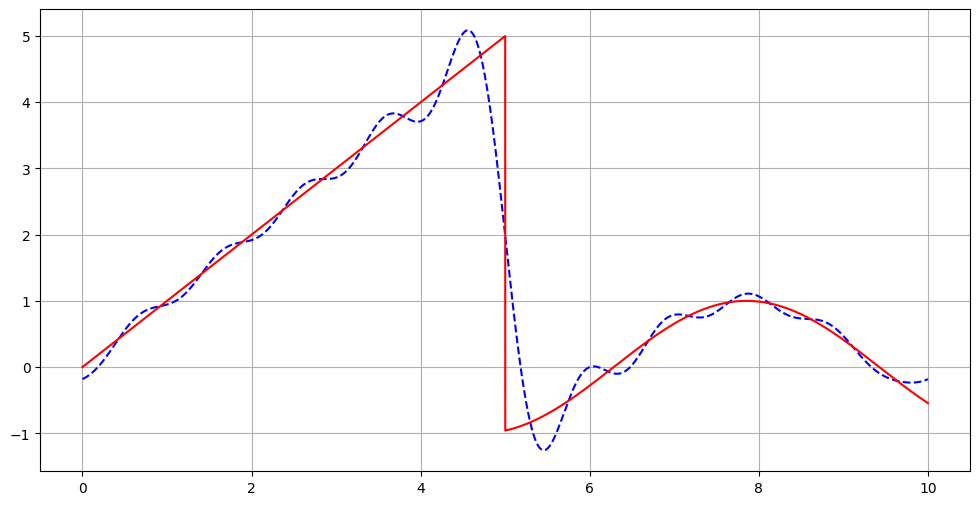

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

k = 10
dx = 0.001
L = 10
x = np.arange(dx, 10+dx, dx)
fx = np.zeros(len(x))
transform = np.zeros(len(x))

fx = np.where(x <= 5, x, np.sin(x))




A0 = np.sum(fx) * dx/L
FS = np.ones(len(x)) * A0

Ak = np.zeros(k)
Bk = np.zeros(k)
for i in range(k):
    Ak[i] = np.sum(fx * np.cos(2 * np.pi * x * (i+1)/L)) * dx *2/L
    Bk[i] = np.sum(fx * np.sin(2 * np.pi * x * (i+1)/L)) * dx * 2/L
    FS = FS + Ak[i] * np.cos(2 * np.pi * x * (i+1)/L) + Bk[i] * np.sin(2 * np.pi * x * (i+1)/L)


plt.figure(figsize=(12,6))
plt.plot(x, FS, marker='', linestyle='--', color = "blue")
plt.plot(x, fx, marker='', linestyle='-', color = "red")
plt.grid(True)
plt.show()
    



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

k = 10
dx = 0.001
L = 10
x = np.arange(dx, L+dx, dx)
def define_fx(x):
    return np.where(x <= 5, x, np.sin(np.pi * x))

def calculate_Fourie(k):

    fx = define_fx(x)
    A0 = np.sum(fx) * dx/L
    FS = np.ones(len(x)) * A0

    Ak = np.zeros(k)
    Bk = np.zeros(k)
    for i in range(k):
        Ak[i] = np.sum(fx * np.cos(2 * np.pi * x * (i+1)/L)) * dx *2/L
        Bk[i] = np.sum(fx * np.sin(2 * np.pi * x * (i+1)/L)) * dx * 2/L
        FS = FS + Ak[i] * np.cos(2 * np.pi * x * (i+1)/L) + Bk[i] * np.sin(2 * np.pi * x * (i+1)/L)


    plt.figure(figsize=(12,6))
    plt.plot(x, FS, marker='', linestyle='--', color = "blue")
    plt.plot(x, fx, marker='', linestyle='-', color = "red")
    plt.grid(True)

for i in range(k):
    if i != 0: plt.pause(0.5)
    calculate_Fourie(i)
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
K = 8
N = 8
n = np.arange(N)
k_vals = np.arange(K)

# Define the original signal x[n]
x = 1 + 0.5 * np.cos(np.pi / 4 * n) + 0.25 * np.sin(np.pi / 2 * n) + 0.125 * np.cos(3 * np.pi / 4 * n + np.pi / 4)

# Define alpha_k[n] = Re{exp(j * pi/4 * k * n)}
alpha = np.array([[np.real(np.exp(1j * np.pi / 4 * k * ni)) for ni in n] for k in k_vals])

# Compute a_k = <alpha_k, x> (inner product)
a_k = np.array([np.dot(alpha_k, x) for alpha_k in alpha])

# Reconstruct signal using x'_A[n] = 1/K * sum(a_k * alpha_k[n])
x_prime = np.sum((a_k[:, np.newaxis] * alpha), axis=0) / K

# Plot the coefficients a_k
plt.figure(figsize=(10, 4))
plt.stem(k_vals, a_k, basefmt=" ")
plt.title("Coefficients $a_k$ of signal $x[n]$ in basis A")
plt.xlabel("k")
plt.ylabel("$a_k$")
plt.grid(True)
plt.tight_layout()
plt.show()

a_k, x, x_prime  # Return the computed coefficients and original and reconstructed signals



In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from ipywidgets import interact
import ipywidgets as widgets

dx = 0.001

def define_fx(x):
     return np.where(x < 0, -np.cos(x), np.where(x <= 5, 0, np.where(x < 12, 2, np.cos(x))))
     #return np.where(x != 100, -x, 0)
     #return np.where(x >= 0, 1, 0 )
 
def calculate_Fourie_symmetrical(k, L, extend_to_negative):
    x = np.arange(-(L+dx), L+dx, dx)
   
    fx = define_fx(x)
    A0 = np.sum(fx)/2 * dx/L
    FS = np.ones(len(x)) * A0

    Ak = np.zeros(k)
    Bk = np.zeros(k)
    for i in range(k):
        Ak[i] = np.sum(fx * np.cos(np.pi * x * (i+1)/L)) * dx/L
        Bk[i] = np.sum(fx * np.sin(np.pi * x * (i+1)/L)) * dx/L
        FS = FS + Ak[i] * np.cos(np.pi * x * (i+1)/L) + Bk[i] * np.sin(np.pi * x * (i+1)/L)



    plt.figure(figsize=(12,6))
    plt.plot(x, FS, marker='', linestyle='--', color = "blue")
    plt.plot(x, fx, marker='', linestyle='-', color = "red")
    plt.grid(True)
    plt.show()


def calculate_Fourie(k, L, extend_to_negative):

    if extend_to_negative :
        calculate_Fourie_symmetrical(k, L, True)
        return
    x = np.arange(dx, L+dx, dx)
   
    fx = define_fx(x)
    A0 = np.sum(fx) * dx/L
    FS = np.ones(len(x)) * A0

    Ak = np.zeros(k)
    Bk = np.zeros(k)
    for i in range(k):
        Ak[i] = np.sum(fx * np.cos(2 * np.pi * x * (i+1)/L)) * dx *2/L
        Bk[i] = np.sum(fx * np.sin(2 * np.pi * x * (i+1)/L)) * dx * 2/L
        FS = FS + Ak[i] * np.cos(2 * np.pi * x * (i+1)/L) + Bk[i] * np.sin(2 * np.pi * x * (i+1)/L)





    plt.figure(figsize=(12,6))
    plt.plot(x, FS, marker='', linestyle='--', color = "blue")
    plt.plot(x, fx, marker='', linestyle='-', color = "red")
    plt.grid(True)
    plt.show()



interact(calculate_Fourie, k=widgets.IntSlider(value = 1,min=1, max=200, step = 1), 
         L = widgets.IntSlider(value = 1,min=1, max=50, step = 1),
         extend_to_negative = widgets.Checkbox(disabled = False, description = 'Extend to negative'))


interactive(children=(IntSlider(value=1, description='k', max=200, min=1), IntSlider(value=1, description='L',…

<function __main__.calculate_Fourie(k, L, extend_to_negative)>